# Các thành viên trong nhóm:

# 1.   52100306 --- Nguyễn Khắc Anh Tài
# 2.   52100312 --- Lê Tuấn Thành
# 3.   52100239 --- Trần Nam Đăng Khoa

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
file_path = "/content/drive/MyDrive/FinalProject_MachineLearning/data/dataset.csv"
df =  pd.read_csv(file_path)

In [6]:
df = df.drop('id', axis=1)

**EDA**

In [7]:
df.shape

(300153, 11)

In [8]:
df.head(5)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Tập dữ liệu gồm tổng cộng có 300261 tùy chọn đặt vé máy bay riêng biệt được trích xuất từ ​​trang web. bộ dữ liệu được thu thập trong 50 ngày, từ ngày 11 tháng 2 đến ngày 31 tháng 3 năm 2022. Nguồn dữ liệu là dữ liệu thứ cấp và được thu thập từ trang web Easy my trip.
Bộ dữ liệu chứa thông tin về các tùy chọn đặt vé máy bay từ trang web Easemytrip dành cho chuyến bay giữa 6 thành phố đô thị hàng đầu của Ấn Độ. Có 300261 điểm dữ liệu và 11 thuộc tính trong tập dữ liệu.
Các thuộc tính khác nhau của tập dữ liệu được giải thích dưới đây:
1.   airline: Tên hãng hàng không.
2.   flight: Thông tin về mã chuyến bay của máy bay.
3.  source_city: Thành phố nơi chuyến bay cất cánh.
4. departure_time: Thuộc tính thu được bằng cách nhóm các khoảng thời gian thành các giá trị thời gian. Nó lưu trữ thông tin về thời gian khởi hành và có 6 nhãn thời gian duy nhất.
5. stops: Thuộc tính có 3 giá trị riêng biệt lưu trữ số điểm dừng giữa thành phố nguồn và thành phố đích.
6. arrival_time: Thuộc tính được tạo bằng cách nhóm các khoảng thời gian thành các giá trị thời gian. Nó có sáu nhãn thời gian riêng biệt và lưu giữ thông tin về thời gian đến.
7. destination_city: Thành phố nơi chuyến bay sẽ hạ cánh.
8. class: Chứa thông tin về hạng ghế; nó có hai giá trị riêng biệt: Thương Gia và Phổ Thông.
9. duration: Tổng thời gian cần thiết để di chuyển giữa các thành phố tính bằng giờ.
10. days_left: Thuộc tính được tính bằng trừ ngày chuyến đi cho ngày đặt vé máy bay.
11. price: Biến mục tiêu lưu trữ thông tin về giá vé

In [9]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [10]:
df.nunique()

airline                 6
flight               1561
source_city             6
departure_time          6
stops                   3
arrival_time            6
destination_city        6
class                   2
duration              476
days_left              49
price               12157
dtype: int64

In [11]:
df.dtypes

airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

In [12]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}: {df[col].unique()}")

airline: ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
flight: ['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433']
source_city: ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
departure_time: ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
stops: ['zero' 'one' 'two_or_more']
arrival_time: ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
destination_city: ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
class: ['Economy' 'Business']


In [13]:
print("Number of null value in each column:", df.isnull().sum())

Number of null value in each column: airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [14]:
print("Number of duplicates value in each column:", df.duplicated().sum())

Number of duplicates value in each column: 0


# **Câu 1:**	Phân tích thống kê trên dữ liệu, vẽ các đồ thị để hiểu bài toán, hiểu dữ liệu. Tìm hiểu các đặc trưng và đánh gía vai trò của các đặc trưng đối với mục tiêu bài toán;

<Axes: xlabel='price', ylabel='Count'>

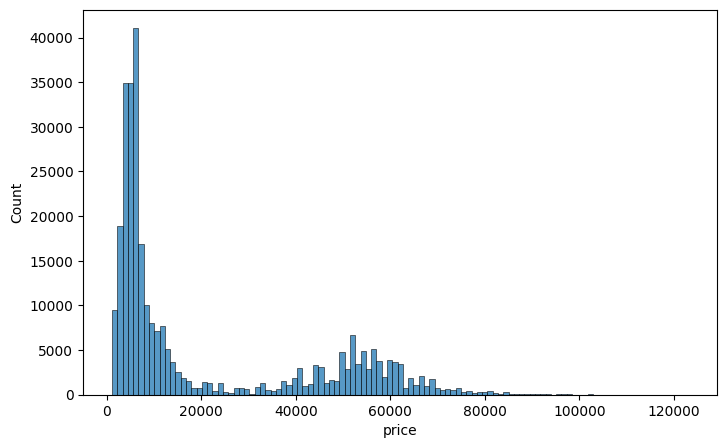

In [15]:
plt.figure(figsize = (18,5))
plt.subplot(1,2,2)
sns.histplot(x = 'price', data = df)

Mặc dù giá trị trung bình là khoảng 20000, nhưng ở đây chúng ta có thể thấy rằng giá trị trung bình của giá vé xấp xỉ 7500. Sự khác biệt này được giải thích bởi sự hiện diện của hai vé khác nhau: Thương gia và Phổ thông



Text(0.5, 1.0, 'Airline prices based on the class and company')

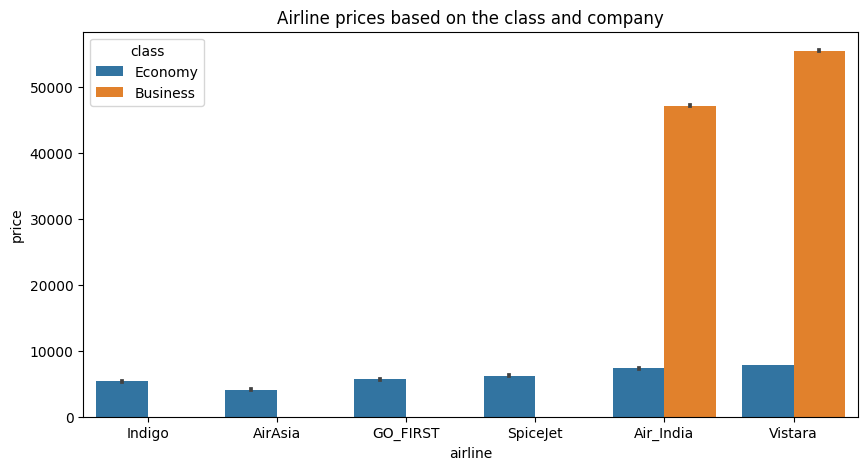

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(x='airline',y='price',hue="class",data=df.sort_values("price")).set_title('Airline prices based on the class and company')

Qua biểu đồ trên, rõ ràng các chuyến bay hạng thương gia được cung cấp độc quyền bởi hai công ty: Air India và Vistara. Điều này cho thấy sự sẵn có hạn chế của các dịch vụ hạng cao cấp từ các hãng hàng không khác. Ngoài ra, có sự chênh lệch đáng kể về giá giữa hai hạng, với vé hạng thương gia có giá gần gấp 5 lần giá vé hạng phổ thông. Khoảng cách giá đáng kể này làm nổi bật tính chất cao cấp và tính độc quyền của trải nghiệm hạng thương gia, phục vụ những hành khách sẵn sàng trả phí để có được sự thoải mái, tiện nghi và dịch vụ nâng cao trong suốt chuyến bay của họ:

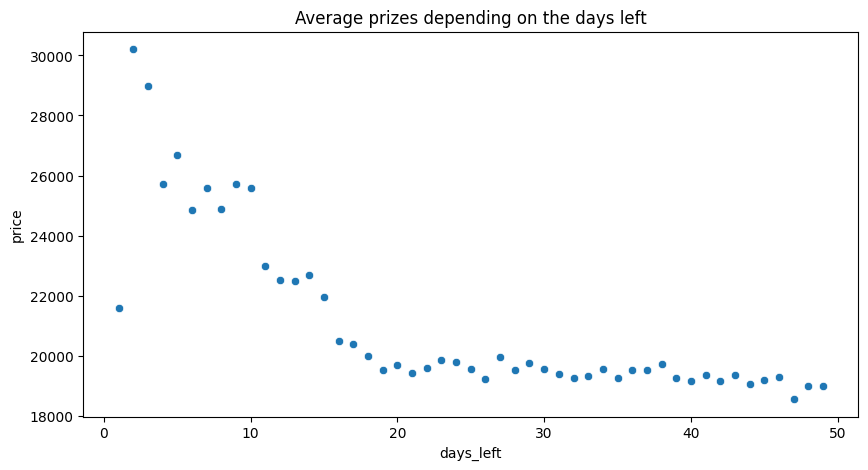

In [17]:
df_temp = df.groupby(['days_left'])['price'].mean().reset_index()
plt.figure(figsize=(10,5))
ax = sns.scatterplot(x="days_left", y="price", data=df_temp).set_title("Average prizes depending on the days left")

Có thể thấy hai đường cong khác nhau trên biểu đồ này, đường cong đầu tiên, ổn định trong khoảng từ 50 đến 20 ngày trước chuyến bay và đường cong đơn điệu tăng dần trong khoảng từ 20 đến 2 ngày trước chuyến bay

<Axes: xlabel='days_left', ylabel='price'>

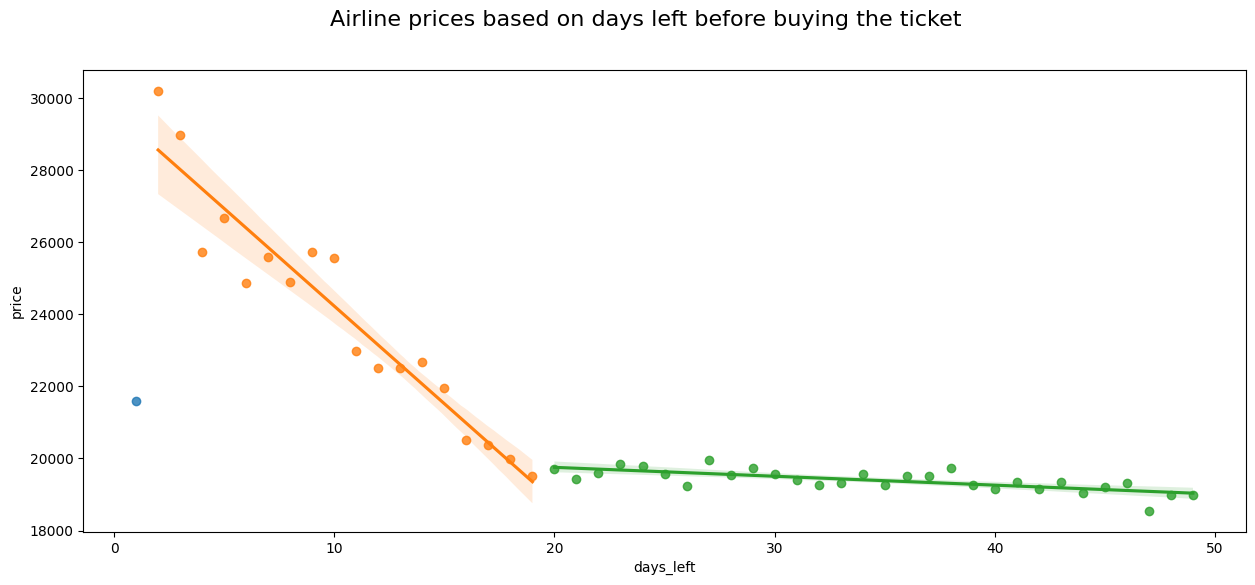

In [18]:
plt.figure(figsize=(15,6)).suptitle('Airline prices based on days left before buying the ticket', fontsize=16)
ax = plt.axes()
sns.regplot(x=df_temp.loc[df_temp["days_left"]==1].days_left, y=df_temp.loc[df_temp["days_left"]==1].price, fit_reg=False, ax=ax)
sns.regplot(x=df_temp.loc[(df_temp["days_left"]>1)&(df_temp["days_left"]<20)].days_left, y=df_temp.loc[(df_temp["days_left"]>1)&(df_temp["days_left"]<20)].price, fit_reg=True, ax=ax)
sns.regplot(x=df_temp.loc[df_temp["days_left"]>=20].days_left, y=df_temp.loc[df_temp["days_left"]>=20].price, fit_reg=True, ax=ax)

Biểu đồ nêu bật cách giá vé tăng chậm và sau đó bắt đầu tăng mạnh 20 ngày trước chuyến bay, nhưng giảm chỉ một ngày trước chuyến bay với giá rẻ hơn tới ba lần. Điều này có thể được giải thích là do các công ty muốn lấp đầy chỗ trống của mình và do đó giảm giá vé để đảm bảo máy bay luôn kín chỗ.

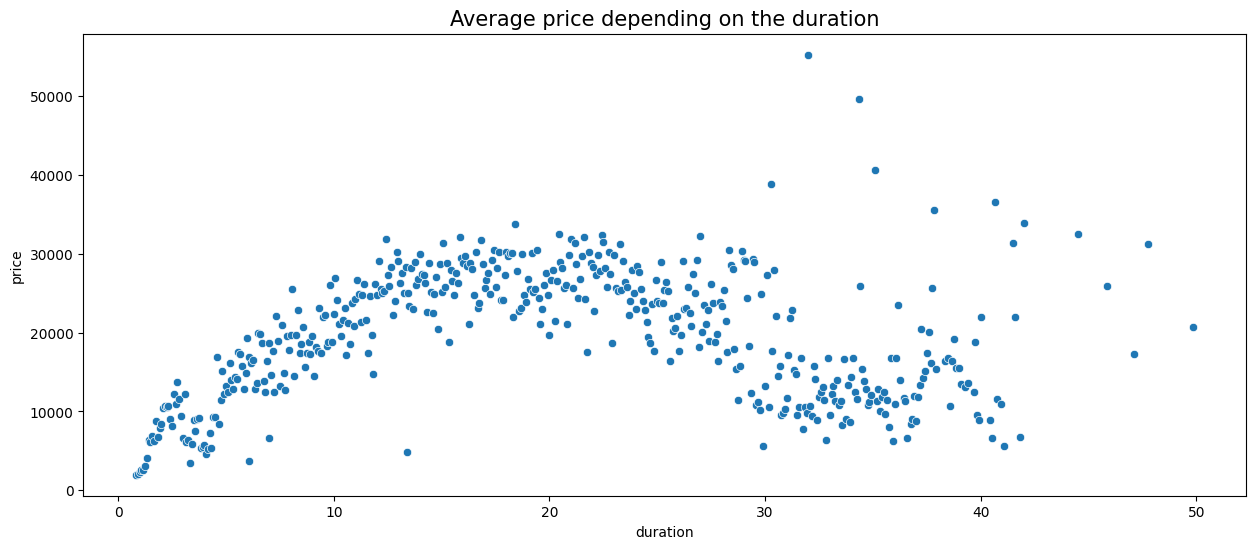

In [19]:
df_temp = df.groupby(['duration'])['price'].mean().reset_index()

plt.figure(figsize=(15,6))
ax = sns.scatterplot(x="duration", y="price", data=df_temp).set_title("Average price depending on the duration",fontsize=15)

Text(0.5, 1.0, 'Airline prices based on the arrival time')

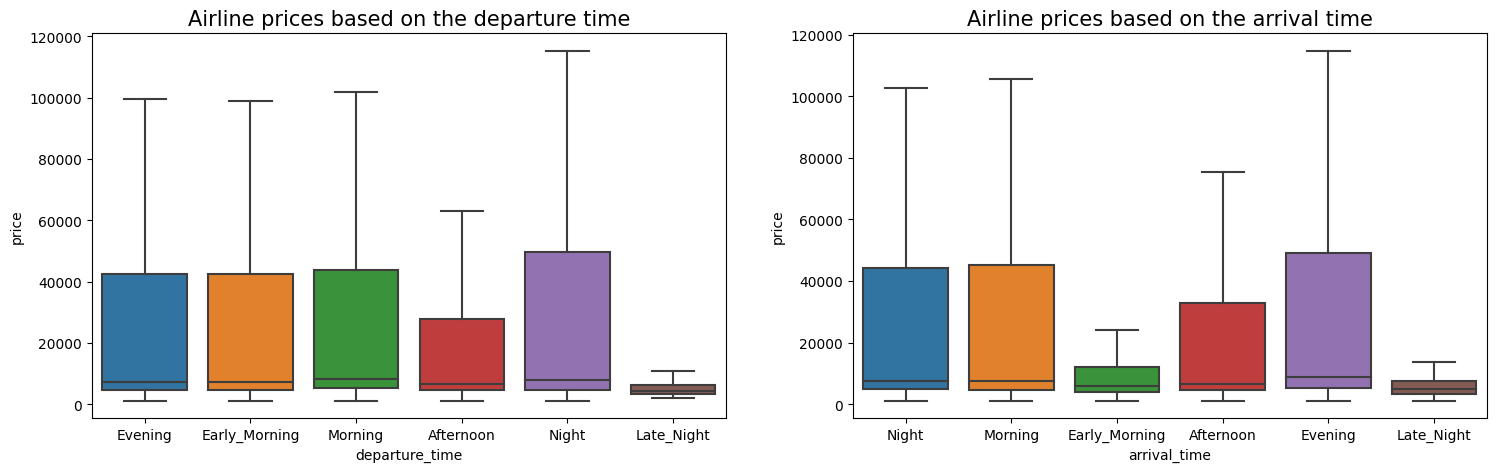

In [20]:
plt.figure(figsize = (18,5))
plt.subplot(1,2,1)
sns.boxplot(data=df, y="price", x="departure_time",showfliers=False).set_title("Airline prices based on the departure time",fontsize=15)
plt.subplot(1,2,2)
sns.boxplot(data=df, y="price", x="arrival_time",showfliers=False).set_title("Airline prices based on the arrival time",fontsize=15)

Đúng như dự đoán, đi vào ban đêm hoặc đến vào ban đêm vẫn là cách đi du lịch rẻ nhất. Nhưng cũng có thể thấy rằng đến vào sáng sớm cũng rẻ và chuyến bay buổi chiều rẻ hơn một chút so với chuyến bay buổi tối, buổi sáng và buổi tối:

Text(0.5, 0.98, 'Airline prices based on the source and destination cities')

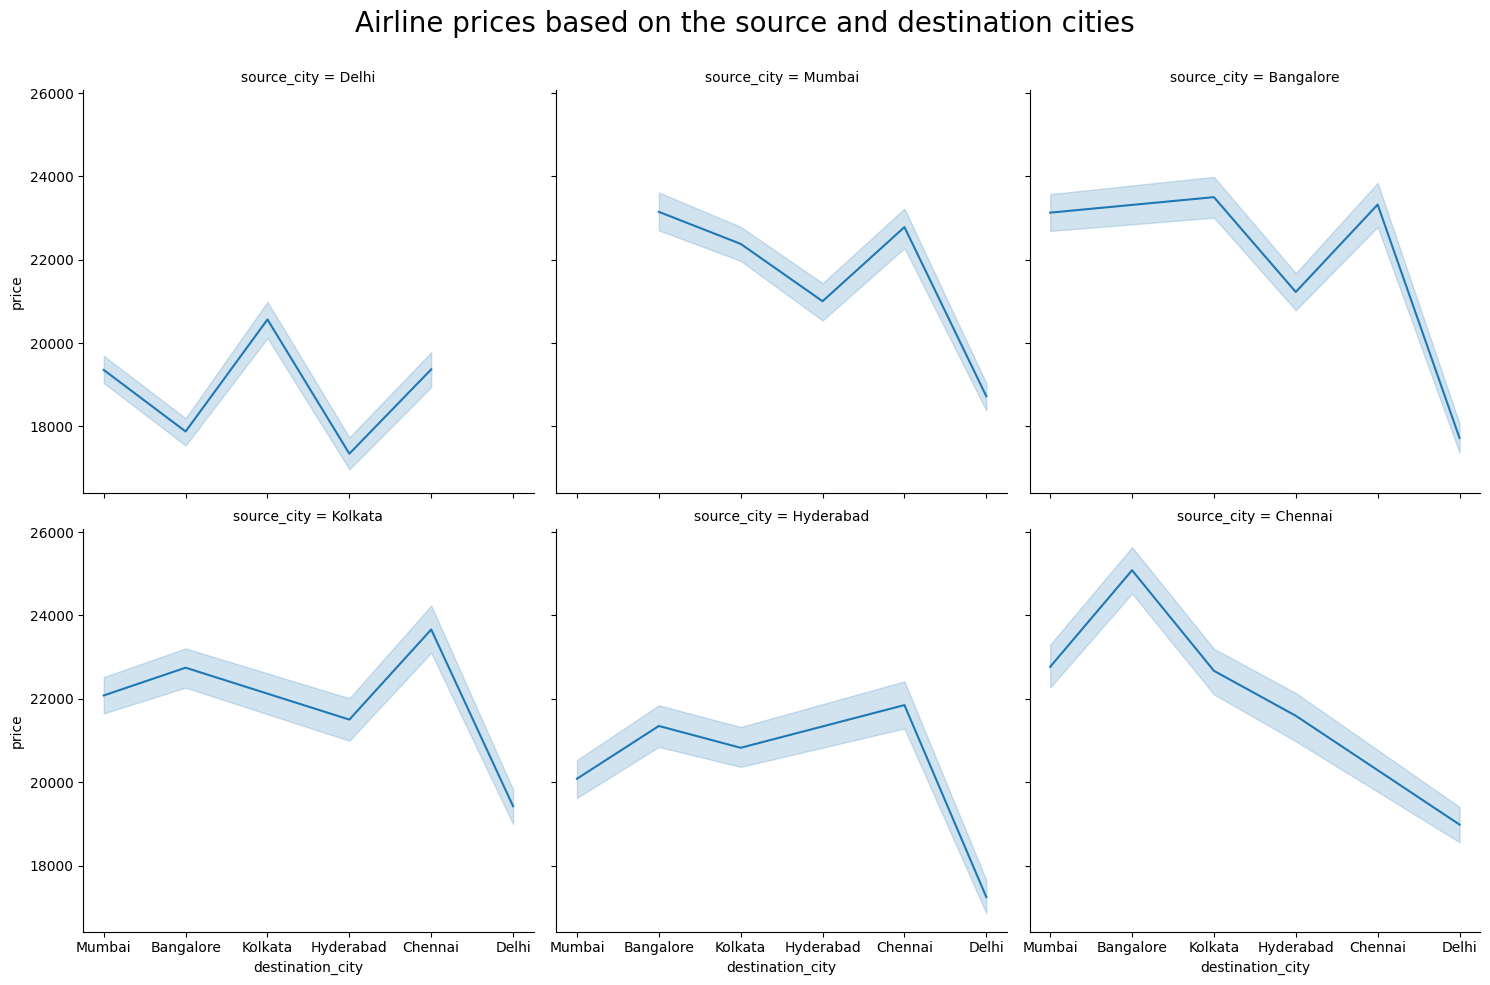

In [21]:
ax = sns.relplot(col="source_city", y="price", kind="line",x='destination_city', data=df, col_wrap=3)
ax.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
ax.fig.suptitle('Airline prices based on the source and destination cities',fontsize=20)

Bên cạnh đó, có vẻ như chuyến bay khởi hành từ Delhi thường rẻ hơn so với các chuyến bay từ các thành phố nguồn khác và thủ đô Delhi cũng là điểm khởi hành rẻ nhất có lẽ vì là thành phố thủ đô, sân bay là sân bay lớn nhất và có nhiều chuyến bay hơn. Mặt khác, giá cả ít nhiều tương tự nhau và Bangalore, Kolkata là điểm đến đắt nhất

Text(0.5, 1.0, 'Airline prices based on the number of stops  for business')

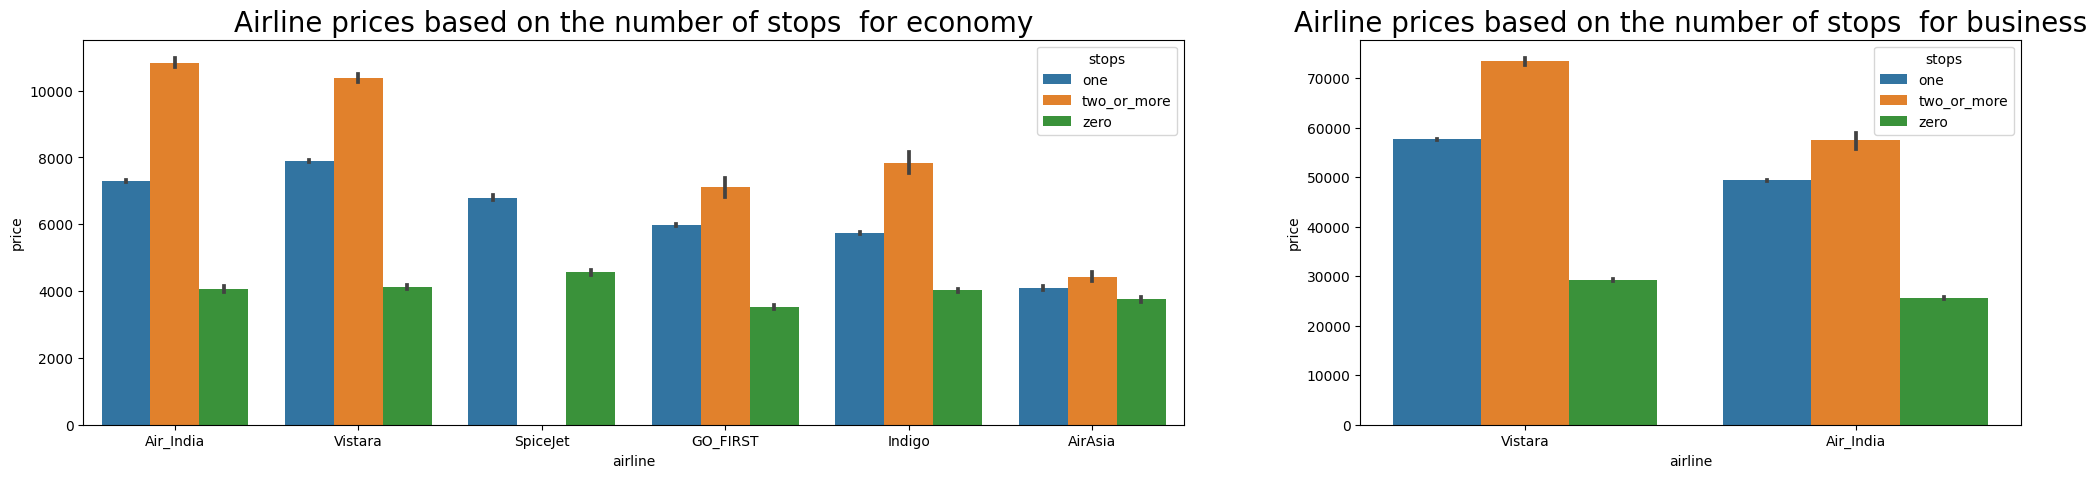

In [22]:
fig, axs = plt.subplots (1, 2, gridspec_kw={'width_ratios': [5, 3]}, figsize=(25, 5))
sns.barplot(y = "price", x = "airline",hue="stops",data = df.loc[df["class"]=='Economy'].sort_values("price", ascending = False), ax=axs[0])
axs[0].set_title("Airline prices based on the number of stops  for economy",fontsize=20)
sns.barplot(y = "price", x = "airline",hue="stops",data = df.loc[df["class"]=='Business'].sort_values("price", ascending = False), ax=axs[1])
axs[1].set_title("Airline prices based on the number of stops  for business",fontsize=20)

Rõ ràng là càng có nhiều điểm dừng thì giá vé của chuyến bay ấy càng đắt tiền, ngoại trừ hãng Air Asia nơi giá cả có vẻ ổn định hơn.

In [23]:
df.corr()

<ipython-input-23-2f6f6606aa2c>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,duration,days_left,price
duration,1.000000,-0.039157,0.204222
days_left,-0.039157,1.000000,-0.091949
price,0.204222,-0.091949,1.000000


<ipython-input-24-1faf16a05a84>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df.corr()


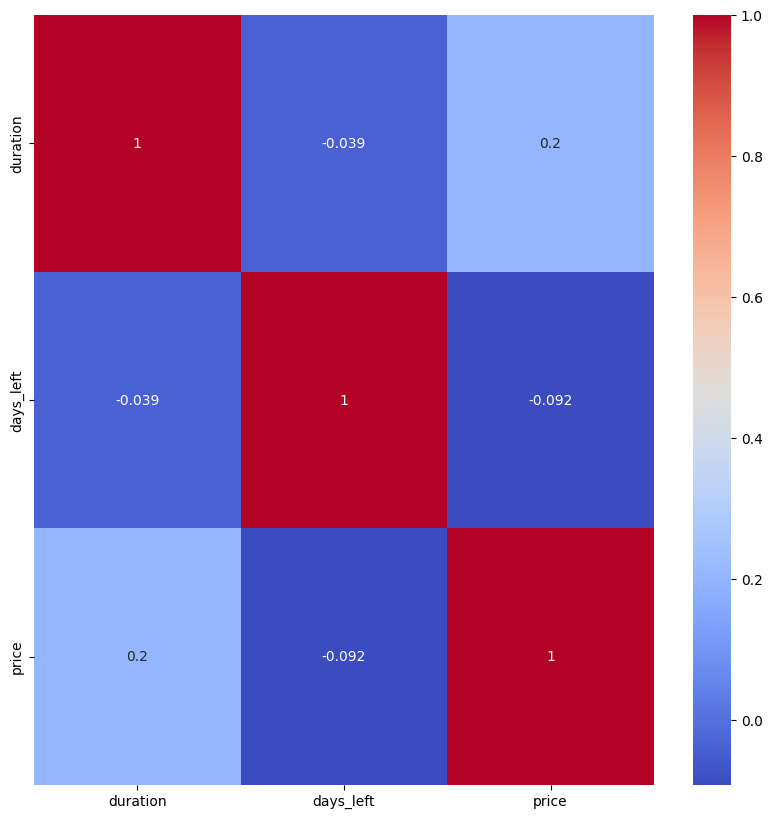

In [24]:

corr_matrix = df.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


 - Mối quan hệ âm giữa giá vé máy và số ngày còn lại trước chuyến đi có thể được hiểu là giá vé giảm khi bạn đặt vé sớm hơn. Điều này có thể là do chiến lược giá theo thời gian đặt vé, với giá thấp hơn cho những người đặt vé trước thời điểm bay.
 - Mối quan hệ dương giữa giá vé máy và thời gian bay có thể có ý nghĩa lý giải. Có thể giả sử rằng các chuyến bay kéo dài lâu hơn, đặc biệt là các chuyến bay trực tiếp hoặc có thời gian bay thuận lợi hơn, thì giá vé có thể cao hơn do sự thuận tiện và chất lượng dịch vụ cao.


# **Câu 2:** Ứng dụng các mô hình học máy cơ bản để giải quyết bài toán, bao gồm cả các mô hình thuộc Ensemble Learing;

**TRANSFORMATION DATA**

In [25]:
print(df)

         airline   flight source_city departure_time stops   arrival_time  \
0       SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1       SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2        AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3        Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4        Vistara   UK-963       Delhi        Morning  zero        Morning   
...          ...      ...         ...            ...   ...            ...   
300148   Vistara   UK-822     Chennai        Morning   one        Evening   
300149   Vistara   UK-826     Chennai      Afternoon   one          Night   
300150   Vistara   UK-832     Chennai  Early_Morning   one          Night   
300151   Vistara   UK-828     Chennai  Early_Morning   one        Evening   
300152   Vistara   UK-822     Chennai        Morning   one        Evening   

       destination_city     class  duration  days_left  price  
0          

Sử dụng LabelEncoder từ thư viện scikit-learn để chuyển đổi các biến kiểu "object" trong DataFrame thành các giá trị số nguyên, làm cho dữ liệu phù hợp với các mô hình học máy:

In [26]:
from sklearn.preprocessing import LabelEncoder

types = df.dtypes
names = df.columns.values.tolist()
le = LabelEncoder()

for i in range(len(types)):
    if types[i] == 'object':
        le.fit_transform(df[names[i]])
        df[names[i]] = le.transform(df[names[i]])

print(df)

        airline  flight  source_city  departure_time  stops  arrival_time  \
0             4    1408            2               2      2             5   
1             4    1387            2               1      2             4   
2             0    1213            2               1      2             1   
3             5    1559            2               4      2             0   
4             5    1549            2               4      2             4   
...         ...     ...          ...             ...    ...           ...   
300148        5    1477            1               4      0             2   
300149        5    1481            1               0      0             5   
300150        5    1486            1               1      0             5   
300151        5    1483            1               1      0             2   
300152        5    1477            1               4      0             2   

        destination_city  class  duration  days_left  price  
0            

**NOMALIZATION** **DATA**

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(df)
print("\nDữ liệu sau khi chuẩn hóa:")
print(scaled_df)


Dữ liệu sau khi chuẩn hóa:
[[0.8        0.9025641  0.4        ... 0.02734694 0.         0.03974878]
 [0.8        0.88910256 0.4        ... 0.03061224 0.         0.03974878]
 [0.         0.7775641  0.4        ... 0.02734694 0.         0.03977338]
 ...
 [1.         0.9525641  0.2        ... 0.26530612 1.         0.6394733 ]
 [1.         0.95064103 0.2        ... 0.18714286 1.         0.65985603]
 [1.         0.94679487 0.2        ... 0.18877551 1.         0.65985603]]


Sử dụng train_test_split để chia dữ liệu thành bộ huấn luyện (X_train, y_train) và bộ kiểm thử (X_test, y_test) với tỷ lệ 70% cho huấn luyện và 30% cho kiểm thử.







In [28]:
from sklearn.model_selection import train_test_split

X = scaled_df[:, :-1]
y = scaled_df[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)

print ("Training size: %d" %len(y_train))
print ("Test size    : %d" %len(y_test))

Training size: 210107
Test size    : 90046


In [48]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [31]:
from sklearn.linear_model import LinearRegression

# Xây dựng mô hình Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_linear = linear_model.predict(X_test)

# Đánh giá mô hình Linear Regression
mse_linear = mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f'Mean Squared Error (Linear Regression): {mse_linear}')
print(f'Mean Absolute Error (Linear Regression): {mae_linear}')
print(f'R^2 Score (Linear Regression): {r2_linear}')

Mean Squared Error (Linear Regression): 0.00333487495882367
Mean Absolute Error (Linear Regression): 0.03813370330167696
R^2 Score (Linear Regression): 0.904312969907109


In [32]:
from sklearn.tree import DecisionTreeRegressor

# Xây dựng mô hình Decision Tree
tree_model = DecisionTreeRegressor()
tree_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_tree = tree_model.predict(X_test)

# Đánh giá mô hình Decision Tree
mse_tree = mean_squared_error(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f'Mean Squared Error (Decision Tree): {mse_tree}')
print(f'Mean Absolute Error (Decision Tree): {mae_tree}')
print(f'R^2 Score (Decision Tree): {r2_tree}')

Mean Squared Error (Decision Tree): 0.0006022179152467629
Mean Absolute Error (Decision Tree): 0.007564757216532872
R^2 Score (Decision Tree): 0.9827206583484553


In [33]:
from sklearn.neighbors import KNeighborsRegressor

# Xây dựng mô hình K-Nearest Neighbors (KNN)
knn_model = KNeighborsRegressor()
knn_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_knn = knn_model.predict(X_test)

# Đánh giá mô hình K-Nearest Neighbors (KNN)
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print(f'Mean Squared Error (KNN): {mse_knn}')
print(f'Mean Absolute Error (KNN): {mae_knn}')
print(f'R^2 Score (KNN): {r2_knn}')

Mean Squared Error (KNN): 0.0009565985647854712
Mean Absolute Error (KNN): 0.015081695437250981
R^2 Score (KNN): 0.9725524714462664


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Xây dựng mô hình Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_rf = rf_model.predict(X_test)

# Đánh giá mô hình Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Mean Squared Error (Random Forest): {mse_rf}')
print(f'Mean Absolute Error (Random Forest): {mae_rf}')
print(f'R^2 Score (Random Forest): {r2_rf}')

Mean Squared Error (Random Forest): 0.00036803450861121846
Mean Absolute Error (Random Forest): 0.007304318424741717
R^2 Score (Random Forest): 0.9894400451184754


In [35]:
from sklearn.ensemble import AdaBoostRegressor

# Xây dựng mô hình AdaBoost
adaboost_model = AdaBoostRegressor(n_estimators=50, learning_rate=0.1, random_state=42)
adaboost_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_adaboost = adaboost_model.predict(X_test)

# Đánh giá mô hình AdaBoost
mse_adaboost = mean_squared_error(y_test, y_pred_adaboost)
mae_adaboost = mean_absolute_error(y_test, y_pred_adaboost)
r2_adaboost = r2_score(y_test, y_pred_adaboost)

print(f'Mean Squared Error (AdaBoost): {mse_adaboost}')
print(f'Mean Absolute Error (AdaBoost): {mae_adaboost}')
print(f'R^2 Score (AdaBoost): {r2_adaboost}')

Mean Squared Error (AdaBoost): 0.002241359147513583
Mean Absolute Error (AdaBoost): 0.02895764950425198
R^2 Score (AdaBoost): 0.9356890429640696


In [36]:
import pandas as pd
from tabulate import tabulate

# Tạo DataFrame với kết quả đánh giá của các mô hình
table = {
    'Model': ['Linear Regression', 'Decision Tree', 'K-Nearest Neighbors', 'Random Forest', 'AdaBoost'],
    'Mean Squared Error': [mse_linear, mse_tree, mse_knn, mse_rf, mse_adaboost],
    'Mean Absolute Error': [mae_linear, mae_tree, mae_knn, mae_rf, mae_adaboost],
    'R^2 Score': [r2_linear, r2_tree, r2_knn, r2_rf, r2_adaboost]
}

data_table = pd.DataFrame(table)
print(tabulate(data_table, headers='keys', tablefmt='fancy_grid'))

╒════╤═════════════════════╤══════════════════════╤═══════════════════════╤═════════════╕
│    │ Model               │   Mean Squared Error │   Mean Absolute Error │   R^2 Score │
╞════╪═════════════════════╪══════════════════════╪═══════════════════════╪═════════════╡
│  0 │ Linear Regression   │          0.00333487  │            0.0381337  │    0.904313 │
├────┼─────────────────────┼──────────────────────┼───────────────────────┼─────────────┤
│  1 │ Decision Tree       │          0.000602218 │            0.00756476 │    0.982721 │
├────┼─────────────────────┼──────────────────────┼───────────────────────┼─────────────┤
│  2 │ K-Nearest Neighbors │          0.000956599 │            0.0150817  │    0.972552 │
├────┼─────────────────────┼──────────────────────┼───────────────────────┼─────────────┤
│  3 │ Random Forest       │          0.000368035 │            0.00730432 │    0.98944  │
├────┼─────────────────────┼──────────────────────┼───────────────────────┼─────────────┤
│  4 │ Ada

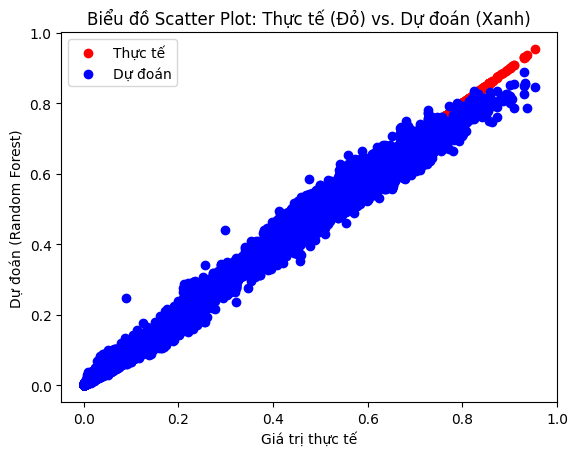

In [37]:
import matplotlib.pyplot as plt

# Dự đoán trên tập huấn luyện
y_train_pred_rf = rf_model.predict(X_train)

# Vẽ biểu đồ scatter plot với màu khác nhau cho dữ liệu thực tế và dự đoán
plt.scatter(y_train, y_train, c='red', label='Thực tế')
plt.scatter(y_train, y_train_pred_rf, c='blue', label='Dự đoán')
plt.xlabel("Giá trị thực tế")
plt.ylabel("Dự đoán (Random Forest)")
plt.title("Biểu đồ Scatter Plot: Thực tế (Đỏ) vs. Dự đoán (Xanh)")
plt.legend()
plt.show()


# **Câu 3:** Sử dụng Feed Forward Neural Network và Reccurent Neural Network (hoặc mô thuộc loại này) để giải quyết bài toán;

# Sử dụng Feed Forward Neural Network (FFNN):

In [45]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Xây dựng mô hình FFNN
ffnn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
ffnn_model.compile(optimizer='adam', loss='mean_squared_error')

# Huấn luyện mô hình
ffnn_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Dự đoán trên tập kiểm tra
y_pred_ffnn = ffnn_model.predict(X_test_scaled).flatten()

# Đánh giá mô hình FFNN
mse_ffnn = mean_squared_error(y_test, y_pred_ffnn)
mae_ffnn = mean_absolute_error(y_test, y_pred_ffnn)
r2_ffnn = r2_score(y_test, y_pred_ffnn)

print(f'Mean Squared Error (FFNN): {mse_ffnn}')
print(f'Mean Absolute Error (FFNN): {mae_ffnn}')
print(f'R^2 Score (FFNN): {r2_ffnn}')


2814/2814 [==============================] - 4s 2ms/step
Mean Squared Error (FFNN): 0.0010744261429477865
Mean Absolute Error (FFNN): 0.019685760327094813
R^2 Score (FFNN): 0.9691716637228587


# Sử dụng Recurrent Neural Network (RNN):

In [47]:
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Xây dựng mô hình RNN
rnn_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=X_train_scaled.shape[1], output_dim=128),
    tf.keras.layers.LSTM(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Dự đoán và đánh giá trên tập kiểm tra
y_pred_rnn = rnn_model.predict(X_test_scaled).flatten()
mse_rnn = mean_squared_error(y_test, y_pred_rnn)
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
r2_score_rnn = r2_score(y_test, y_pred_rnn)

print('Đánh giá mô hình RNN:')
print(f'Mean Squared Error (RNN): {mse_rnn}')
print(f'Mean Absolute Error (RNN): {mae_rnn}')
print(f'R^2 Score (RNN): {r2_score_rnn}')

2814/2814 [==============================] - 13s 4ms/step
Đánh giá mô hình RNN:
Mean Squared Error (RNN): 0.0024532158723493927
Mean Absolute Error (RNN): 0.03272761128492628
R^2 Score (RNN): 0.92961027207909


# **Câu 4:**	Áp dụng các kỹ thuật tránh Overfiting trên các mô hình của câu (2) và câu (3) để giải quyết bài toán;

Linear Regression

In [49]:
from sklearn.linear_model import Ridge

# Xây dựng mô hình Linear Regression với Ridge regularization
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Đánh giá mô hình Ridge
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f'Mean Squared Error (Ridge): {mse_ridge}')
print(f'Mean Absolute Error (Ridge): {mae_ridge}')
print(f'R^2 Score (Ridge): {r2_ridge}')


Mean Squared Error (Ridge): 0.003334879206681404
Mean Absolute Error (Ridge): 0.03813389434317215
R^2 Score (Ridge): 0.9043128480240111


Trước và sau khi áp dụng phương pháp tránh Overfitting thì các chỉ số MSE, MAE và R2 đều không đổi

Decison Tree

In [50]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Xây dựng mô hình Decision Tree với các tham số để điều chỉnh
tree_model = DecisionTreeRegressor(max_depth=None, min_samples_split=2, min_samples_leaf=1)

# Tìm kiếm tham số tối ưu bằng GridSearchCV
param_grid = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(tree_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Lấy mô hình tốt nhất sau khi điều chỉnh tham số
best_tree_model = grid_search.best_estimator_

# Dự đoán trên tập kiểm tra
y_pred_tree = best_tree_model.predict(X_test)

# Đánh giá mô hình Decision Tree đã điều chỉnh
mse_tree = mean_squared_error(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f'Mean Squared Error (Decision Tree): {mse_tree}')
print(f'Mean Absolute Error (Decision Tree): {mae_tree}')
print(f'R^2 Score (Decision Tree): {r2_tree}')

Mean Squared Error (Decision Tree): 0.0004810289019119036
Mean Absolute Error (Decision Tree): 0.008833231792619677
R^2 Score (Decision Tree): 0.9861979151898905


Đây là các chỉ số của trước khi áp dụng phương pháp tránh Overfitting:
- Mean Squared Error (Decision Tree): 0.0006022179152467629
- Mean Absolute Error (Decision Tree): 0.007564757216532872
- R^2 Score (Decision Tree): 0.9827206583484553

Có thể thấy không những không tăng, thậm chí chỉ số R2 còn bị giảm hiệu suất một chút sau khi áp dụng phương pháp tránh Overfitting

KNN

In [51]:
from sklearn.neighbors import KNeighborsRegressor

# Xây dựng mô hình K-Nearest Neighbors (KNN) với các tham số để tránh overfitting
knn_model = KNeighborsRegressor(
    n_neighbors=5,    # Số lân cận
    weights='distance'  # Trọng số ('distance' hoặc 'uniform')
)

knn_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_knn = knn_model.predict(X_test)

# Đánh giá mô hình K-Nearest Neighbors (KNN) đã chỉnh tham số
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print(f'Mean Squared Error (KNN): {mse_knn}')
print(f'Mean Absolute Error (KNN): {mae_knn}')
print(f'R^2 Score (KNN): {r2_knn}')


Mean Squared Error (KNN): 0.0009512844762127626
Mean Absolute Error (KNN): 0.014622914332258248
R^2 Score (KNN): 0.9727049477338189


- Mean Squared Error (KNN): 0.0009565985647854712
- Mean Absolute Error (KNN): 0.015081695437250981
- R^2 Score (KNN): 0.9725524714462664

Tương tự, sau khi áp dụng phương pháp tránh Overfitting thì chỉ số R2 cũng giảm đi đôi chút.

Random Forest

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Tách tập dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Điều chỉnh các tham số của Random Forest để tránh overfitting
rf_model = RandomForestRegressor(
    n_estimators=50,       # Giảm số cây
    max_depth=10,           # Giảm độ sâu tối đa của cây
    min_samples_split=5,    # Điều chỉnh min_samples_split
    min_samples_leaf=2,     # Điều chỉnh min_samples_leaf
    random_state=42
)

# Huấn luyện mô hình
rf_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_rf = rf_model.predict(X_test)

# Đánh giá mô hình Random Forest đã được điều chỉnh
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Mean Squared Error (Random Forest): {mse_rf}')
print(f'Mean Absolute Error (Random Forest): {mae_rf}')
print(f'R^2 Score (Random Forest): {r2_rf}')


Mean Squared Error (Random Forest): 0.0009751241493405835
Mean Absolute Error (Random Forest): 0.017626023200409197
R^2 Score (Random Forest): 0.9718154197185531


Adaboost Regressor

In [54]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Tách tập dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Điều chỉnh các tham số của AdaBoost để tránh overfitting
adaboost_model = AdaBoostRegressor(
    n_estimators=50,      # Số cây
    learning_rate=0.1,     # Tỉ lệ học
    random_state=42
)

# Huấn luyện mô hình
adaboost_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_adaboost = adaboost_model.predict(X_test)

# Đánh giá mô hình AdaBoost đã được điều chỉnh
mse_adaboost = mean_squared_error(y_test, y_pred_adaboost)
mae_adaboost = mean_absolute_error(y_test, y_pred_adaboost)
r2_adaboost = r2_score(y_test, y_pred_adaboost)

print(f'Mean Squared Error (AdaBoost): {mse_adaboost}')
print(f'Mean Absolute Error (AdaBoost): {mae_adaboost}')
print(f'R^2 Score (AdaBoost): {r2_adaboost}')


Mean Squared Error (AdaBoost): 0.002253336728083447
Mean Absolute Error (AdaBoost): 0.028892705685078377
R^2 Score (AdaBoost): 0.9348704983291122


Feed Forward Neural Network

In [41]:
from tensorflow.keras.regularizers import l2

# Xây dựng mô hình FFNN với L2 regularization
ffnn_model_reg = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    tf.keras.layers.Dense(1)
])

ffnn_model_reg.compile(optimizer='adam', loss='mean_squared_error')

# Huấn luyện mô hình
ffnn_model_reg.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Dự đoán trên tập kiểm tra
y_pred_ffnn_reg = ffnn_model_reg.predict(X_test_scaled).flatten()

# Đánh giá mô hình FFNN với L2 regularization
mse_ffnn_reg = mean_squared_error(y_test, y_pred_ffnn_reg)
mae_ffnn_reg = mean_absolute_error(y_test, y_pred_ffnn_reg)
r2_ffnn_reg = r2_score(y_test, y_pred_ffnn_reg)

print(f'Mean Squared Error (FFNN with L2 regularization): {mse_ffnn_reg}')
print(f'Mean Absolute Error (FFNN with L2 regularization): {mae_ffnn_reg}')
print(f'R^2 Score (FFNN with L2 regularization): {r2_ffnn_reg}')


2814/2814 [==============================] - 4s 1ms/step
Mean Squared Error (FFNN with L2 regularization): 0.0024626112547732016
Mean Absolute Error (FFNN with L2 regularization): 0.03020766635944738
R^2 Score (FFNN with L2 regularization): 0.9293406918843835


Reccurent Neural Network

In [52]:
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Xây dựng mô hình RNN với lớp dropout
rnn_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=X_train_scaled.shape[1], output_dim=128),
    tf.keras.layers.LSTM(64, activation='relu', dropout=0.2, recurrent_dropout=0.2),
    tf.keras.layers.Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Dự đoán và đánh giá trên tập kiểm tra
y_pred_rnn = rnn_model.predict(X_test_scaled).flatten()
mse_rnn = mean_squared_error(y_test, y_pred_rnn)
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
r2_score_rnn = r2_score(y_test, y_pred_rnn)

print('Đánh giá mô hình RNN:')
print(f'Mean Squared Error (RNN): {mse_rnn}')
print(f'Mean Absolute Error (RNN): {mae_rnn}')
print(f'R^2 Score (RNN): {r2_score_rnn}')


2814/2814 [==============================] - 14s 5ms/step
Đánh giá mô hình RNN:
Mean Squared Error (RNN): 0.0024511126736774507
Mean Absolute Error (RNN): 0.03259415112327544
R^2 Score (RNN): 0.9296706188198518


# **Câu 5:**	Sau khi huấn luyện xong mô hình thì muốn cải thiện độ chính xác, ta sẽ làm gì để giải quyết nó? Phân tích các trường hợp sai, đề ra giải pháp và thực hiện nó, sau đó đánh giá xem có cải tiến so với trước không.

**Sau khi huấn luyện xong mô hình thì muốn cải thiện độ chính xác, ta sẽ làm gì để giải quyết nó?**
- Tăng kích thước tập dữ liệu: Tập dữ liệu càng lớn thì mô hình càng có nhiều thông tin để học và từ đó có thể dự đoán chính xác hơn.
- Sử dụng các kỹ thuật giảm overfitting: Các kỹ thuật giảm overfitting như L1/L2 regularization, cắt tỉa cây,... có thể giúp giảm độ phức tạp của mô hình và từ đó cải thiện độ chính xác.
- Thử nghiệm các mô hình khác nhau: Có nhiều loại mô hình học máy khác nhau, mỗi loại có những ưu nhược điểm riêng. Bạn có thể thử nghiệm các mô hình khác nhau để tìm ra mô hình phù hợp nhất với bài toán của mình.
- Tìm hiểu thêm về dữ liệu: Bạn có thể tìm hiểu thêm về dữ liệu của mình, chẳng hạn như phân phối dữ liệu, các mối quan hệ giữa các thuộc tính,...



**Phân tích các trường hợp sai, đề ra giải pháp và thực hiện nó, sau đó đánh giá xem có cải tiến so với trước không.**